<a href="https://colab.research.google.com/github/LeonardoALMacedo/Calculo-Numerico/blob/main/Atividade%20II/cn_atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico - Atividade prática 2

## Identificação

Nome: Luan Groppo Viana

RA: 177103

Nome: Rodrigo Lopes Marques

RA: 180385

Nome: Leonardo Arantes Lopes Macedo

RA: 176558

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 400 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 400 passos sem overflow.
dt=0.002, float64: 400 passos sem overflow.


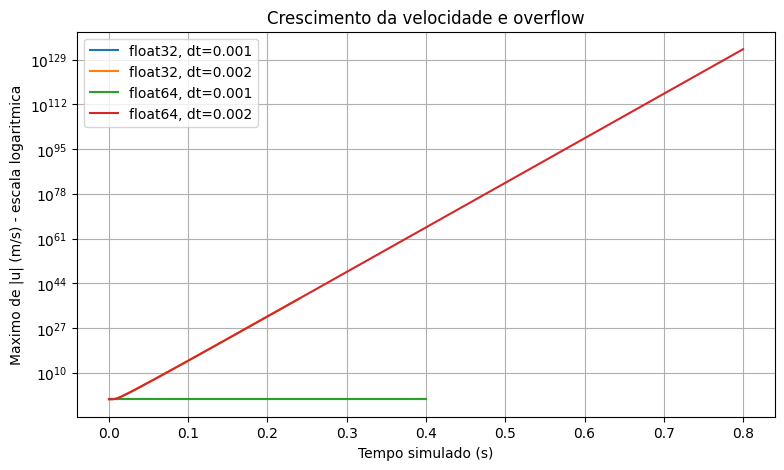

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=400, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

## 1. Verificação da estabilidade
Calcule $\Delta t$, $\Delta t_{max}$ e $r$ para os casos A e B. Classifique cada caso como estável ou instável antes de executar o programa.

$$
\Delta y = \frac{H}{20}, \quad \Delta t_{max} = \frac{\Delta y^2}{2\nu},\quad r = \dfrac{\nu \Delta t}{\Delta y^2}
$$


###Resposta:
No caso A e B, $\Delta y$ e $\Delta t_{max}$ são os mesmos, sendo os valores dados na tabela do exercício. O que muda será o $\Delta r$ e $\Delta t$.

$\Delta y = 0.0005 m$

$\Delta t_{max} = \frac{0.0005^2}{2\cdot 10^{-4}} = 0.00125 s$

No caso A:

$\Delta r = \dfrac{10^{-4} \cdot {0.001}}{0.0005^2} = 0,4$

O caso A é estável, pois $\Delta r = 0,4 \le 0,5$ e $\Delta t \le \Delta t_{max}$

No caso B:

$\Delta r = \dfrac{10^{-4} \cdot {0.002}}{0.0005^2} = 0,8$

O caso B é instável, pois $\Delta r = 0,8 \gt 0,5$ e $\Delta t \gt \Delta t_{max}$

## 2. Detecção de overflow.

Com a excução dos 4 testes, obtivemos como output:
```
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add
```

Dessa forma, podemos montar a tabela:

### Tabela dos testes

| Tipo numérico | Δt (s) | r | Estável? (r ≤ 0,5) | Overflow | Iteração da falha | t da falha (s) | max \|u\| final |
|---|---|---|---|---|---|---|---|
| float32 | 0,001 | 0,40 | sim | não | — | — | 1,0000e+00 |
| float32 | 0,002 | 0,80 | não | sim | 121 | 0,2420 | 1,6659e+38 |
| float64 | 0,001 | 0,40 | sim | não | — | — | 1,0000e+00 |
| float64 | 0,002 | 0,80 | não | sim | 917 | 1,8340 | 4,7434e+307 |


## 3. Interpretação física.

Temos que o sistema não é estável para valores de $r > 1/2$, porque
$
\begin{equation*}
u_i^{n+1} = r u^n_{i-1} + (1-2r)u^n_i + r u^n_{i+1}.
\end{equation*}
$
Dessa forma, $u_i$ no instante $n+1$ cresce de forma inversa ao valor de $u_i$ no instante $n$, o que é um absurdo. Com isso, observamos que o modelo usado não funciona para valores com $r > 1/2$.

Para esse caso específico, temos $r=0.8$. Assim, como $u_i^1 \le 1$, a combinação linear de $u_{i-1}^1, u_i^1, u_{i+1}^1$ está no intervalo $[-0.6, 1.6]$. Para a próxima iteração, teríamos o valor no intervalo $[(-0.6)^2, (1.6)^2]$. Continuando dessa forma, observamos que não temos um limite superior para o valor e overflow ocorre em algum momento.

## 4. Capacidade de representação.

A mudança de tipo numérico não eliminou a instabilidade, apenas aumentou o número de iterações até a falha. Com o float32 falhou na iteração 121, e com float64 falhou na iteração 917, com uma diferença de 796 passos. Note que o modelo não é instável, pois $r = 0.8 \ge \frac{1}{2}$. Como vimos no texto acima, os valores não têm um limite máximo e podem crescer infinitamente. Dessa forma, temos que o tipo de variável que armazenamos os dados apenas altera a quantidade de passos até dar overflow.

## 5. Refinamento da malha.

Com 41 pontos:

$$
\Delta y = \frac{H}{41-1} = \frac{0{,}01}{40} = 2{,}5 \times 10^{-4}\ \text{m}
$$

$$
\Delta t_{max} = \frac{\Delta y^2}{2\nu} = \frac{(2{,}5 \times 10^{-4})^2}{2 \times 10^{-4}} = 3{,}125 \times 10^{-4}\ \text{s}
$$

Mantendo $\Delta t = 0{,}001$ s:

$$
r = \frac{\nu \Delta t}{\Delta y^2} = \frac{10^{-4} \times 0{,}001}{(2{,}5 \times 10^{-4})^2} = 1{,}6
$$

Ou seja, $r = 1{,}6 > 0{,}5$ -> instável. O $\Delta t$ que era estável na malha de 21 pontos ($r = 0{,}4$) passou a violar o limite, porque refinar a malha reduz $\Delta y$ pela metade e, como $\Delta t_{max} \propto \Delta y^2$, o limite de estabilidade cai por um fator 4 (de $1{,}25 \times 10^{-3}$ s para $3{,}125 \times 10^{-4}$ s).

Executanto o teste:

```
dt=0.001, float32, pontos=41: falha no passo 56,  t=0.0560 s - overflow encountered in multiply
dt=0.001, float64, pontos=41: falha no passo 426, t=0.4260 s - overflow encountered in subtract
```

Escolhendo $\Delta t = 2 \times 10^{-4}$ s $< \Delta t_{max}$:

$$
r = \frac{10^{-4} \times 2 \times 10^{-4}}{(2{,}5 \times 10^{-4})^2} = 0{,}32 \le 0{,}5 \quad \Rightarrow \quad \text{estável}
$$

```
dt=0.0002, float32, pontos=41: 2000 passos sem overflow. max|u| = 1,0000e+00
dt=0.0002, float64, pontos=41: 2000 passos sem overflow. max|u| = 1,0000e+00
```

| Pontos | $\Delta y$ (m) | $\Delta t$ (s) | $r$ | Estável? | Overflow | Iteração da falha |
|---|---|---|---|---|---|---|
| 41 | $2{,}5 \times 10^{-4}$ | 0,001 | 1,60 | não | sim (float32) | 56 |
| 41 | $2{,}5 \times 10^{-4}$ | 0,001 | 1,60 | não | sim (float64) | 426 |
| 41 | $2{,}5 \times 10^{-4}$ | 0,0002 | 0,32 | sim | não | — |

Conclusão: refinar a malha não é gratuito, exige reduzir $\Delta t$ na proporção de $\Delta y^2$ para manter $r \le 1/2$. Com $r = 0{,}32$ a solução permanece limitada em $0 \le u \le U$, como esperado fisicamente.


## 6. Verificação do perfil de velocidade.

Tempo total simulado: 0.4000 s
Diferença máxima (E_infinity): 1.211994e-02


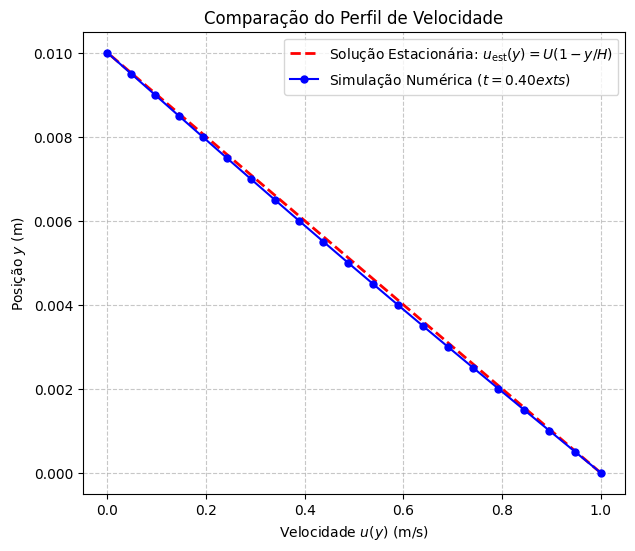

In [ ]:
res_estavel = resultados["float64, dt=0.001"]

y_sim = res_estavel["y"]
u_num = res_estavel["u"]
tempo_total = res_estavel["tempos"][-1]

H = 0.01
U = 1.0
u_est = U * (1 - y_sim / H)

E_inf = np.max(np.abs(u_num - u_est))

print(f"Tempo total simulado: {tempo_total:.4f} s")
print(f"Diferença máxima (E_infinity): {E_inf:.6e}")

plt.figure(figsize=(7, 6))
plt.plot(u_est, y_sim, 'r--', linewidth=2, label=r'Solução Estacionária: $u_{\text{est}}(y) = U(1 - y/H)$')
plt.plot(u_num, y_sim, 'bo-', markersize=5, label=f'Simulação Numérica ($t = {tempo_total:.2f}\text{{ s}}$)')

plt.title("Comparação do Perfil de Velocidade")
plt.xlabel("Velocidade $u(y)$ (m/s)")
plt.ylabel("Posição $y$ (m)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.show()

## 7. Conclusão
A análise da simulação evidencia o impacto direto dos tipos de precisão numérica (float32 e float64) e da variação do passo de tempo na estabilidade do método.

Ao analisar o passo e tempo, observa-se que, para $t = 0,001s$ a simulação manteve-se totalmente estável ao longo dos 400 passos tanto em float32 quanto em float64, preservando os valores de velocidade dentro dos limites físicos esperados.

Ao aumentar o passo de tempo para $t = 0,002s$ o método numérico perdeu sua estabilidade, que se manifestou de formas diferentes dependendo da precisão numérica usada no teste.

Em float32 a variação provocou um crescimento exponencial das velocidades até resultar em um erro de overflow no passo 121, por outro lado, usando float64 a simulação não apresentou overflow nos 300 passos devido ao limite de representação numérica.


Para o modelo utilizado, temos que $r \le 1/2$ mantém estabilidade do sistema. Suponha, por exemplo, o aumento de pontos da malha. Temos
$$
\Delta y = \frac{H}{\text{QtPontos}-1}, \quad r = \dfrac{\nu \Delta t}{\Delta y^2}.
$$
Logo, refinar a malha reduz $\Delta y$, o que aumenta $r$. Também temos que aumentar o passo de tempo aumenta proporcionalmente $r$. Assim, mantendo valores de $\Delta t$ e $\Delta y$ tais que
$$
\dfrac{\nu \Delta t}{\Delta y^2} = r \le \dfrac{1}{2}.
$$
temos que o modelo simula o comportamento físico real e não ocorre o aumento exponencial dos valores de $u_i$, que geram o overflow.